In [ ]:
# ✅ Orden correcto
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin-1")

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

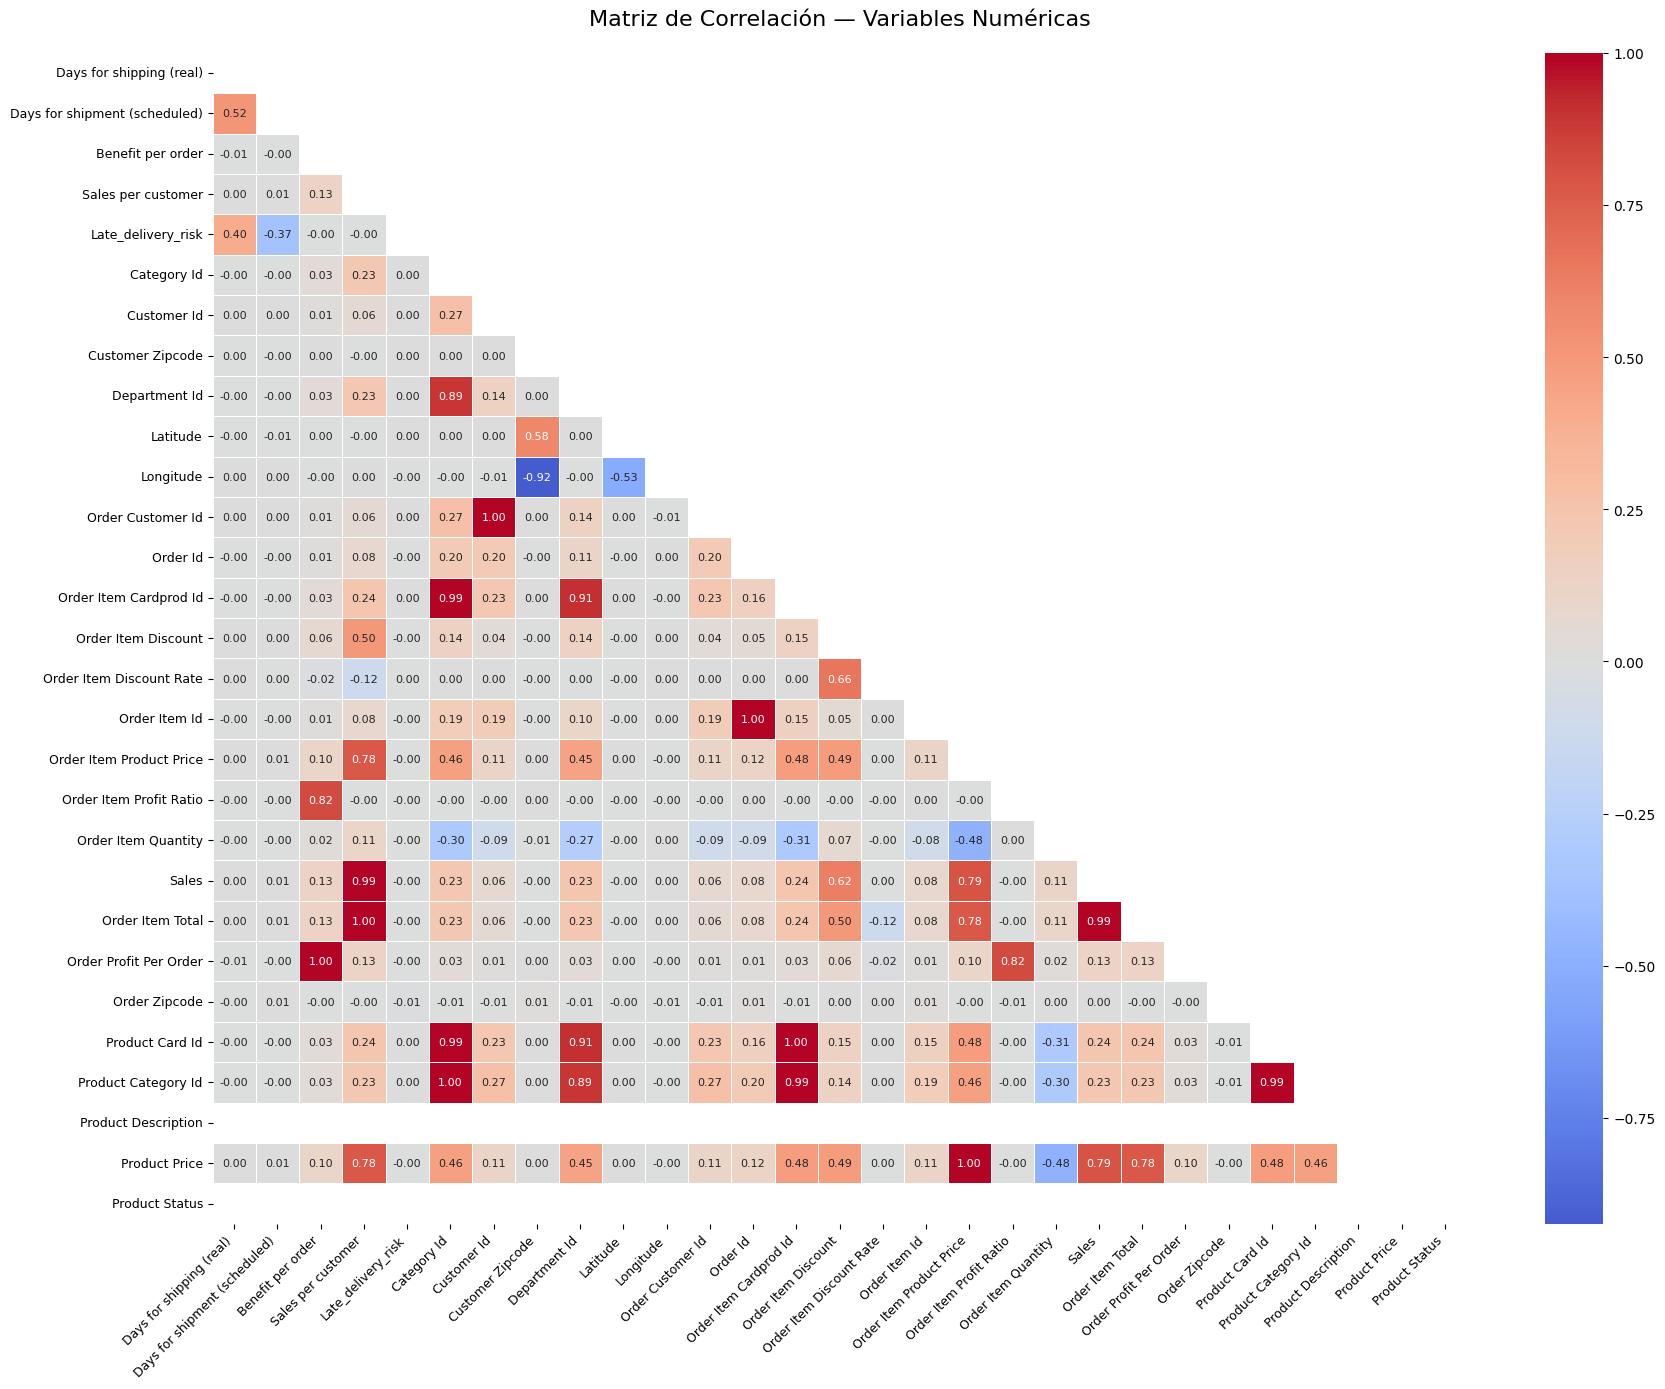


Correlaciones con Late_delivery_risk (ordenadas por valor absoluto):
Days for shipping (real)         0.401415
Days for shipment (scheduled)   -0.369352
Order Zipcode                   -0.014131
Sales per customer              -0.003791
Order Item Total                -0.003791
Order Profit Per Order          -0.003727
Benefit per order               -0.003727
Sales                           -0.003564
Customer Zipcode                 0.003148
Order Item Profit Ratio         -0.002316
Product Price                   -0.002175
Order Item Product Price        -0.002175
Longitude                       -0.001915
Category Id                      0.001752
Product Category Id              0.001752
Product Card Id                  0.001490
Order Item Cardprod Id           0.001490
Customer Id                      0.001484
Order Customer Id                0.001484
Order Item Id                   -0.001376
Order Id                        -0.001293
Department Id                    0.001077
Order 

In [16]:
# Matriz de correlación — solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # oculta triángulo superior (duplicado)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print('\nCorrelaciones con Late_delivery_risk (ordenadas por valor absoluto):')
print(corr_matrix['Late_delivery_risk'].drop('Late_delivery_risk').sort_values(key=abs, ascending=False).to_string())


In [17]:
# Separación de variables predictoras (X) y variable objetivo (y)

TARGET = 'Sales'

# Columnas a excluir: objetivo, IDs sin valor predictivo, columnas con fuga de datos o todo nulo
drop_cols = [
    TARGET,
    # IDs — sin valor predictivo
    'Customer Id', 'Order Customer Id', 'Order Id',
    'Order Item Id', 'Order Item Cardprod Id',
    'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id',
    # Fuga de datos (data leakage) — derivadas de Sales
    'Order Item Total',       # = Sales * Quantity
    'Order Profit Per Order', # depende de Sales
    'Benefit per order',      # depende de Sales
    # Sin datos útiles
    'Product Description',    # 0 non-null
]

# Solo columnas numéricas (el modelo no acepta texto directamente)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Predictores: numéricas que no están en drop_cols
feature_cols = [c for c in numeric_cols if c not in drop_cols]

X = df[feature_cols]
y = df[TARGET]

print(f"Variables predictoras ({len(feature_cols)}):")
print(feature_cols)
print(f"\nVariable objetivo: '{TARGET}'")
print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")


Variables predictoras (15):
['Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Late_delivery_risk', 'Customer Zipcode', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Order Zipcode', 'Product Price', 'Product Status']

Variable objetivo: 'Sales'

Forma de X: (180519, 15)
Forma de y: (180519,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 80% entrenamiento — 20% prueba
    random_state=42   # semilla para reproducibilidad
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")


X_train: (144415, 15)
X_test:  (36104, 15)
y_train: (144415,)
y_test:  (36104,)


In [ ]:
# ✅ Correcto
import time

from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Definición de modelos ──────────────────────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Lasso":             Lasso(alpha=1.0, max_iter=5000),
    "ElasticNet":        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
}

# ── Benchmarking ───────────────────────────────────────────────────────────────
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # ← rellena NaN con la mediana
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = pipe.predict(X_test)

    results.append({
        "Modelo":    name,
        "MAE":       mean_absolute_error(y_test, y_pred),
        "RMSE":      root_mean_squared_error(y_test, y_pred),
        "R²":        r2_score(y_test, y_pred),
        "Tiempo(s)": round(elapsed, 4),
    })

# ── Tabla comparativa ──────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("Modelo")
results_df = results_df.sort_values("R²", ascending=False)

print("=" * 60)
print("           BENCHMARKING — MODELOS DE REGRESIÓN")
print("=" * 60)
print(results_df.to_string(float_format="{:.4f}".format))
print("\n✅ Mejor modelo por R²:", results_df["R²"].idxmax())
print("✅ Menor MAE:",           results_df["MAE"].idxmin())
print("✅ Menor RMSE:",          results_df["RMSE"].idxmin())

           BENCHMARKING — MODELOS DE REGRESIÓN
                      MAE    RMSE     R²  Tiempo(s)
Modelo                                             
Linear Regression  0.0006  0.0015 1.0000     0.2100
Ridge              0.0017  0.0033 1.0000     0.1744
Lasso              0.8359  1.1550 0.9999     0.2073
ElasticNet        21.3449 30.1334 0.9476     0.2736

✅ Mejor modelo por R²: Linear Regression
✅ Menor MAE: Linear Regression
✅ Menor RMSE: Linear Regression


Features (18): ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Customer Zipcode', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Price', 'Product Status']
Distribución del target:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Accuracy: 0.9743

               precision    recall  f1-score   support

No tardío (0)       1.00      0.94      0.97     16308
   Tardío (1)       0.96      1.00      0.98     19796

     accuracy                           0.97     36104
    macro avg       0.98      0.97      0.97     36104
 weighted avg       0.98      0.97      0.97     36104



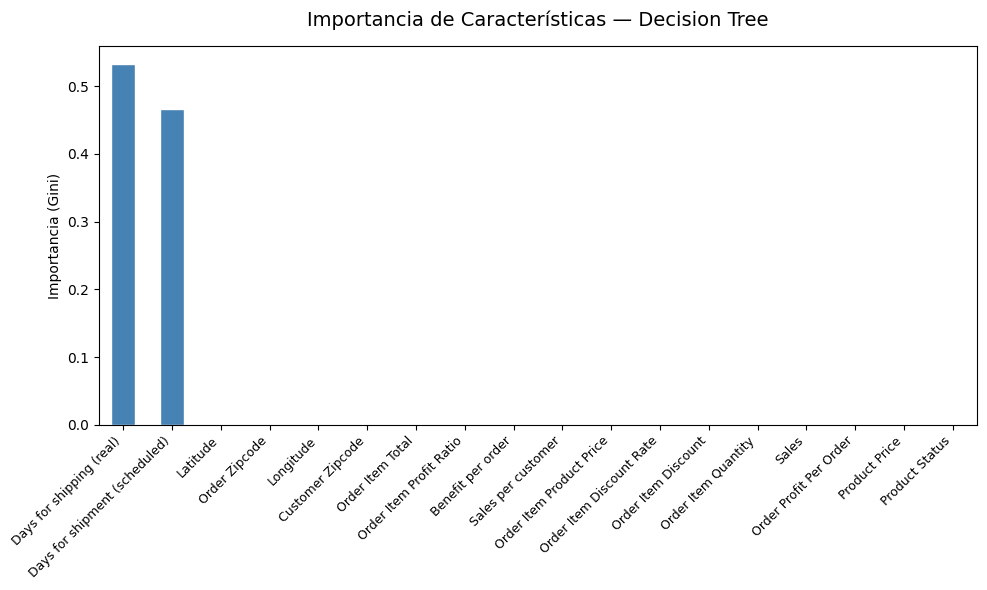


Top 5 características más importantes:
Days for shipping (real)        0.5323
Days for shipment (scheduled)   0.4670
Latitude                        0.0002
Order Zipcode                   0.0002
Longitude                       0.0001


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# ── 1. Definir target y features ───────────────────────────────────────────────
TARGET_CLF = 'Late_delivery_risk'

drop_cols_clf = [
    TARGET_CLF,
    # IDs sin valor predictivo
    'Customer Id', 'Order Customer Id', 'Order Id',
    'Order Item Id', 'Order Item Cardprod Id',
    'Product Card Id', 'Product Category Id', 'Category Id', 'Department Id',
    # Sin datos útiles
    'Product Description',
]

numeric_cols_clf = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_clf = [c for c in numeric_cols_clf if c not in drop_cols_clf]

X_clf = df[feature_cols_clf]
y_clf = df[TARGET_CLF]

print(f"Features ({len(feature_cols_clf)}): {feature_cols_clf}")
print(f"Distribución del target:\n{y_clf.value_counts()}")

# ── 2. Split entrenamiento / prueba ────────────────────────────────────────────
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf      # mantiene proporción de clases en ambos conjuntos
)

# ── 3. Pipeline + entrenamiento ────────────────────────────────────────────────
dt_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   DecisionTreeClassifier(max_depth=6, random_state=42)),
])

dt_pipe.fit(X_train_clf, y_train_clf)
y_pred_clf = dt_pipe.predict(X_test_clf)

# ── 4. Evaluación ──────────────────────────────────────────────────────────────
print(f"\nAccuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}\n")
print(classification_report(y_test_clf, y_pred_clf,
                             target_names=["No tardío (0)", "Tardío (1)"]))

# ── 5. Importancia de características ─────────────────────────────────────────
importances = pd.Series(
    dt_pipe.named_steps["model"].feature_importances_,
    index=feature_cols_clf
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Importancia de Características — Decision Tree", fontsize=14, pad=15)
ax.set_ylabel("Importancia (Gini)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 características más importantes:")
print(importances.head(5).to_string(float_format="{:.4f}".format))


In [21]:
# ── 1. Selección de features por importancia (umbral > 1%) ────────────────────
IMPORTANCE_THRESHOLD = 0.01  # descartar features con importancia < 1%

selected_features = importances[importances >= IMPORTANCE_THRESHOLD].index.tolist()

print(f"Features seleccionadas ({len(selected_features)}):")
for feat in selected_features:
    print(f"  {feat:<35} {importances[feat]:.4f}")

# ── 2. Separación X / y ────────────────────────────────────────────────────────
X_final = df[selected_features]
y_final = df[TARGET_CLF]

print(f"\nForma de X_final: {X_final.shape}")
print(f"Forma de y_final: {y_final.shape}")
print(f"\nValores nulos en X_final:\n{X_final.isnull().sum()}")

# ── 3. Split entrenamiento / prueba ────────────────────────────────────────────
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

print(f"\nConjunto de entrenamiento : X={X_train_f.shape} | y={y_train_f.shape}")
print(f"Conjunto de prueba        : X={X_test_f.shape}  | y={y_test_f.shape}")
print(f"\nDistribución en entrenamiento:\n{y_train_f.value_counts(normalize=True).mul(100).round(2).astype(str) + '%'}")
print(f"\nDistribución en prueba:\n{y_test_f.value_counts(normalize=True).mul(100).round(2).astype(str) + '%'}")


Features seleccionadas (2):
  Days for shipping (real)            0.5323
  Days for shipment (scheduled)       0.4670

Forma de X_final: (180519, 2)
Forma de y_final: (180519,)

Valores nulos en X_final:
Days for shipping (real)         0
Days for shipment (scheduled)    0
dtype: int64

Conjunto de entrenamiento : X=(144415, 2) | y=(144415,)
Conjunto de prueba        : X=(36104, 2)  | y=(36104,)

Distribución en entrenamiento:
Late_delivery_risk
1    54.83%
0    45.17%
Name: proportion, dtype: str

Distribución en prueba:
Late_delivery_risk
1    54.83%
0    45.17%
Name: proportion, dtype: str


✔ Logistic Regression    entrenado en 0.0888s
✔ Decision Tree          entrenado en 0.0389s
✔ Random Forest          entrenado en 0.6729s
✔ XGBoost                entrenado en 0.6116s

              BENCHMARKING — MODELOS DE CLASIFICACIÓN
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Tiempo(s)
Modelo                                                                        
Logistic Regression    0.9745     0.9555  1.0000    0.9772   0.9727     0.0888
Decision Tree          0.9745     0.9555  1.0000    0.9772   0.9728     0.0389
Random Forest          0.9745     0.9555  1.0000    0.9772   0.9728     0.6729
XGBoost                0.9745     0.9555  1.0000    0.9772   0.9728     0.6116

🏆 Mejor Accuracy : Logistic Regression
🏆 Mejor F1-Score : Logistic Regression
🏆 Mejor ROC-AUC  : Decision Tree


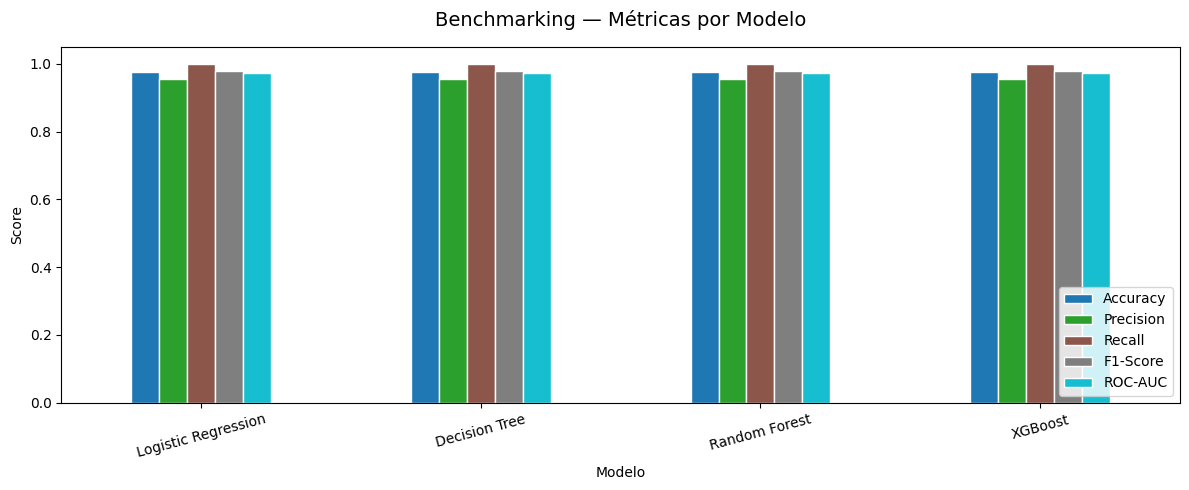

In [ ]:
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# ── Definición de modelos ──────────────────────────────────────────────────────
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=6,
                                                  random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, max_depth=6,
                                         learning_rate=0.1, random_state=42,
                                         eval_metric="logloss",
                                         verbosity=0),
}

# ── Benchmarking ───────────────────────────────────────────────────────────────
clf_results = []

for name, model in clf_models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])

    start = time.time()
    pipe.fit(X_train_f, y_train_f)
    elapsed = time.time() - start

    y_pred  = pipe.predict(X_test_f)
    y_proba = pipe.predict_proba(X_test_f)[:, 1]

    clf_results.append({
        "Modelo":      name,
        "Accuracy":    accuracy_score(y_test_f, y_pred),
        "Precision":   precision_score(y_test_f, y_pred, zero_division=0),
        "Recall":      recall_score(y_test_f, y_pred, zero_division=0),
        "F1-Score":    f1_score(y_test_f, y_pred, zero_division=0),
        "ROC-AUC":     roc_auc_score(y_test_f, y_proba),
        "Tiempo(s)":   round(elapsed, 4),
    })
    print(f"✔ {name:<22} entrenado en {elapsed:.4f}s")

# ── Tabla comparativa ──────────────────────────────────────────────────────────
clf_results_df = pd.DataFrame(clf_results).set_index("Modelo")
clf_results_df = clf_results_df.sort_values("F1-Score", ascending=False)

print("\n" + "=" * 72)
print("              BENCHMARKING — MODELOS DE CLASIFICACIÓN")
print("=" * 72)
print(clf_results_df.to_string(float_format="{:.4f}".format))

print(f"\n🏆 Mejor Accuracy : {clf_results_df['Accuracy'].idxmax()}")
print(f"🏆 Mejor F1-Score : {clf_results_df['F1-Score'].idxmax()}")
print(f"🏆 Mejor ROC-AUC  : {clf_results_df['ROC-AUC'].idxmax()}")

# ── Visualización ──────────────────────────────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

clf_results_df[metrics].plot(
    kind="bar", figsize=(12, 5), colormap="tab10",
    edgecolor="white", rot=15
)
plt.title("Benchmarking — Métricas por Modelo", fontsize=14, pad=15)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

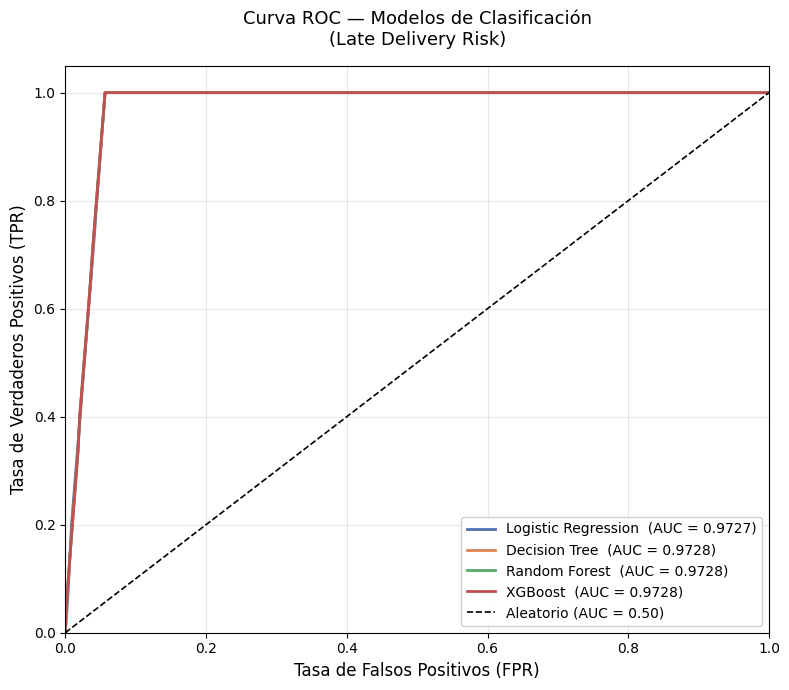

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# ── Modelos (misma config que el benchmarking) ─────────────────────────────────
clf_models_roc = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=6,
                                                  random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=100, max_depth=6,
                                         learning_rate=0.1, random_state=42,
                                         eval_metric="logloss", verbosity=0),
}

# ── Figura ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for (name, model), color in zip(clf_models_roc.items(), colors):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   model),
    ])
    pipe.fit(X_train_f, y_train_f)
    y_proba = pipe.predict_proba(X_test_f)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_f, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC = {roc_auc:.4f})")

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Aleatorio (AUC = 0.50)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
ax.set_title("Curva ROC — Modelos de Clasificación\n(Late Delivery Risk)", fontsize=13, pad=15)
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
